This notebook loads the saved predictions and residuals from four separately trained models — Linear Regression, Random Forest, XGBoost, and LSTM — all built to predict Bitcoin's (BTC-USD) closing price from the same engineered OHLCV-based feature set. It compares their performance side by side using evaluation metrics (MAE, MSE, RMSE, R²), prediction plots and residual analysis.

In [1]:
!pip install tensorflow
!pip install keras
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.7 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

In [3]:
# Load data
btc_ticker = yf.Ticker("BTC-USD")
if os.path.exists("btc.csv"):
    btc = pd.read_csv("btc.csv", index_col=0)
else:
    btc = btc_ticker.history(start="2014-09-17", end="2024-09-01")
    btc.to_csv("btc.csv")

In [4]:
# Preprocess the data
btc = btc.drop(columns=["Dividends", "Stock Splits"])
btc.index = pd.to_datetime(btc.index)
btc.index = btc.index.tz_localize(None)

# Handle missing values (if any)
btc.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1408/3629015112.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  btc.fillna(method='ffill', inplace=True)


In [5]:
btc

,Open,High,Low,Close,Volume
Date,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100
...,...,...,...,...,...
2024-08-27,62879.707031,63210.796875,58116.750000,59504.132812,39103882198
2024-08-28,59507.925781,60236.449219,57890.675781,59027.625000,40289564698
2024-08-29,59027.468750,61184.082031,58786.226562,59388.179688,32224990582


In [6]:
import pickle

# Load the Series from files

with open('y_pred_rf.pkl', 'rb') as f:
    y_pred_rf = pickle.load(f)
with open('residuals_rf.pkl', 'rb') as f:
    residuals_rf = pickle.load(f)
with open('scaled_values_rf.pkl', 'rb') as f:
    scaled_values_rf = pickle.load(f)
with open('y_pred_xgb.pkl', 'rb') as f:
    y_pred_xgb = pickle.load(f)
with open('residuals_xgb.pkl', 'rb') as f:
    residuals_xgb = pickle.load(f)
with open('scaled_values_xgb.pkl', 'rb') as f:
    scaled_values_xgb = pickle.load(f)
with open('y_pred_lr.pkl', 'rb') as f:
    y_pred_lr = pickle.load(f)
with open('residuals_lr.pkl', 'rb') as f:
    residuals_lr = pickle.load(f)
with open('scaled_values_lr.pkl', 'rb') as f:
    scaled_values_lr = pickle.load(f)
with open('y_pred_lstm.pkl', 'rb') as f:
    y_pred_lstm = pickle.load(f)
with open('residuals_lstm.pkl', 'rb') as f:
    residuals_lstm = pickle.load(f)
with open('scaled_values_lstm.pkl', 'rb') as f:
    scaled_values_lstm = pickle.load(f)
with open('y_test_index.pkl', 'rb') as f:
    y_test_index = pickle.load(f)

In [7]:
print(len(y_pred_lr))
print(len(y_pred_rf))
print(len(y_pred_xgb))
print(len(y_pred_lstm))

727
727
727
698


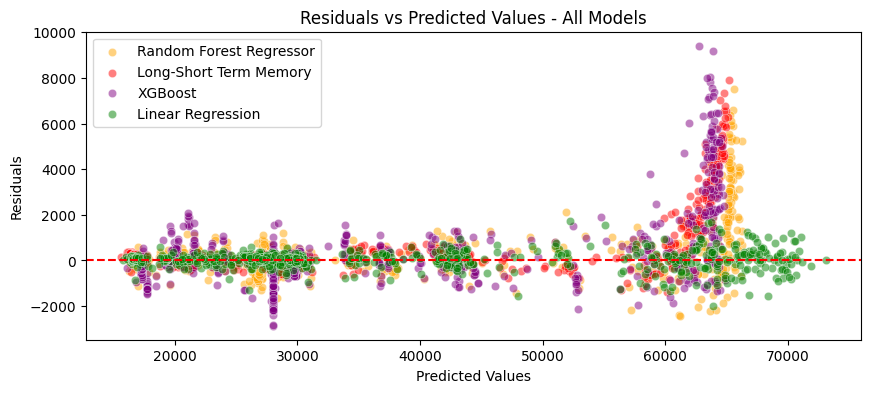

In [8]:
# Calculate residuals
import seaborn as sns
import matplotlib.pyplot as plt

# Plot residuals using seaborn
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_pred_rf[30:], y=residuals_rf, alpha=0.5, color="orange", label="Random Forest Regressor")
sns.scatterplot(x=y_pred_lstm.flatten(), y=residuals_lstm, alpha=0.5, color="red", label="Long-Short Term Memory")
sns.scatterplot(x=y_pred_xgb[30:], y=residuals_xgb, alpha=0.5, color="purple", label="XGBoost")
sns.scatterplot(x=y_pred_lr[31:], y=residuals_lr, alpha=0.5, color="green", label="Linear Regression")
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values - All Models')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.show()

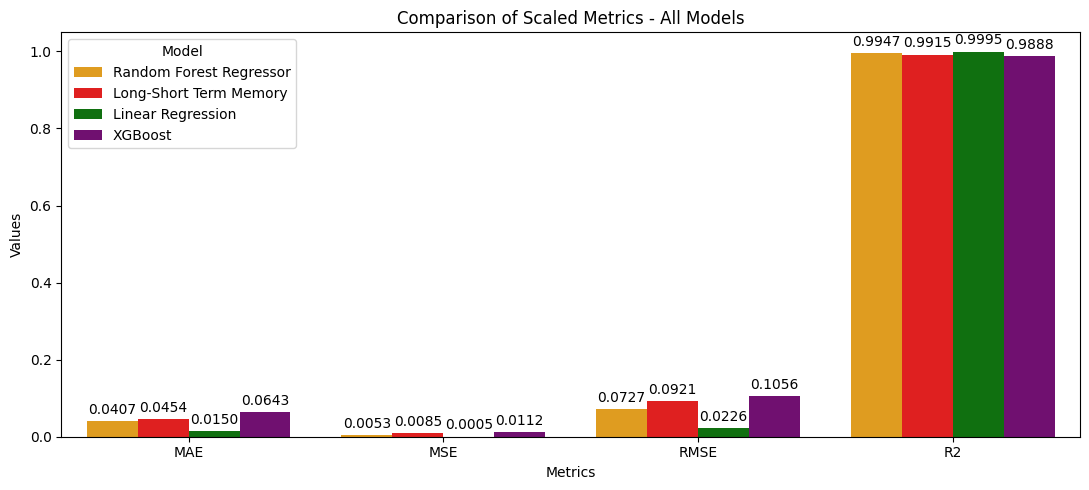

In [9]:
#PROBA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Prepare data for plotting
metrics = ['MAE', 'MSE', 'RMSE', 'R2']
models = ['RandomForest', 'LSTM', 'LinearRegression', 'XGBoost']

# Create a DataFrame for better visualization with Seaborn
metrics_df = pd.DataFrame({
    'Metric': metrics * 4,  # Repeat metrics list for each model
    'Value': scaled_values_rf + scaled_values_lstm + scaled_values_lr + scaled_values_xgb,
    'Model': ['Random Forest Regressor'] * 4 + ['Long-Short Term Memory'] * 4 + ['Linear Regression'] * 4 + ['XGBoost'] * 4
})

plt.figure(figsize=(11, 5))
ax = sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df,
                 palette={'Random Forest Regressor': 'orange', 'Long-Short Term Memory': 'red', 'Linear Regression': 'green', 'XGBoost': 'purple'})

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Comparison of Scaled Metrics - All Models')

# Function to label the bars
def autolabel(rects, ax):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        # Only add a label if the height is above a small threshold
        if height > 0.0001:  # Adjust threshold as needed
            ax.annotate(f'{height:.4f}',  # rounded to 4 decimal places
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

# Apply the autolabel function
rects = ax.patches
autolabel(rects, ax)

plt.tight_layout()
plt.show()


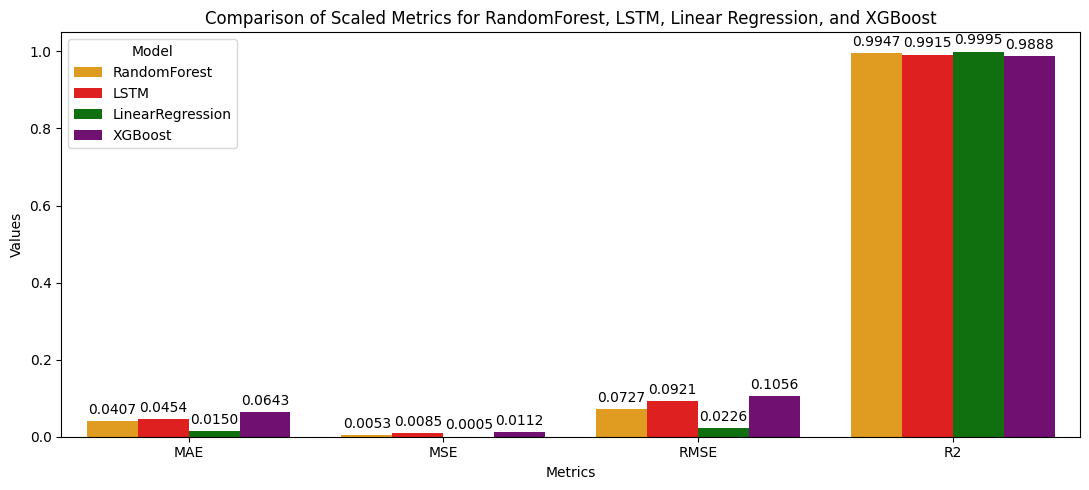

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Prepare data for plotting
metrics = ['MAE', 'MSE', 'RMSE', 'R2']
models = ['RandomForest', 'LSTM', 'LinearRegression', 'XGBoost']

# Create a DataFrame for better visualization with Seaborn
metrics_df = pd.DataFrame({
    'Metric': metrics * 4,  # Repeat metrics list for each model
    'Value': scaled_values_rf + scaled_values_lstm + scaled_values_lr + scaled_values_xgb,
    'Model': ['RandomForest'] * 4 + ['LSTM'] * 4 + ['LinearRegression'] * 4 + ['XGBoost'] * 4
})

plt.figure(figsize=(11, 5))
ax = sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df,
                 palette={'RandomForest': 'orange', 'LSTM': 'red', 'LinearRegression': 'green', 'XGBoost': 'purple'})

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Comparison of Scaled Metrics for RandomForest, LSTM, Linear Regression, and XGBoost')

# Function to label the bars
def autolabel(rects, ax):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        # Only add a label if the height is above a small threshold
        if height > 0.0001:  # Adjust threshold as needed
            ax.annotate(f'{height:.4f}',  # rounded to 4 decimal places
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

# Apply the autolabel function
rects = ax.patches
autolabel(rects, ax)

plt.tight_layout()
plt.show()


In [12]:
y_pred_series_lstm = pd.Series(y_pred_lstm.flatten(), index=y_test_index[-len(y_pred_lstm.flatten()):])

Text(0.5, 0, 'Date')

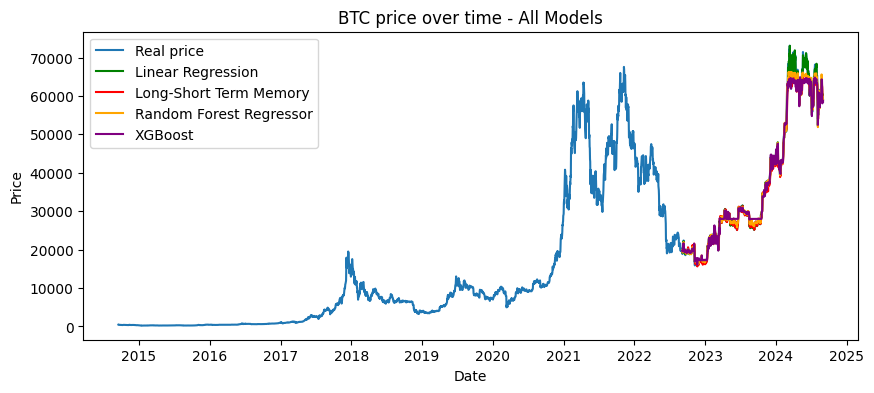

In [13]:
plt.figure(figsize=(10,4))

# Add title
plt.title("BTC price over time - All Models")

# Line chart
sns.lineplot(data=btc["Close"], label="Real price")

# Line chart
sns.lineplot(data=y_pred_lr, label="Linear Regression", color="green")
sns.lineplot(data=y_pred_series_lstm, label="Long-Short Term Memory", color="red")
sns.lineplot(data=y_pred_rf, label="Random Forest Regressor", color="orange")
sns.lineplot(data=y_pred_xgb, label="XGBoost", color="purple")

# Add legend
plt.legend()

# Add label for vertical axis
plt.ylabel("Price")

# Add label for horizontal axis
plt.xlabel("Date")

Text(0.5, 0, 'Date')

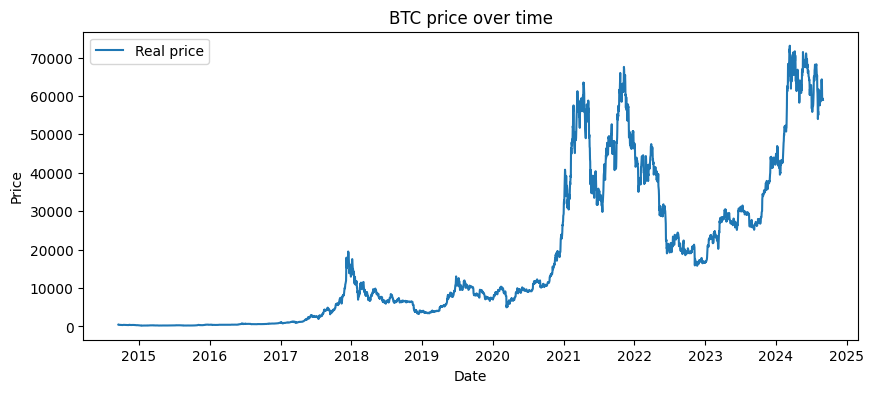

In [14]:
plt.figure(figsize=(10,4))

# Add title
plt.title("BTC price over time")

# Line chart
sns.lineplot(data=btc["Close"], label="Real price")

# Add legend
plt.legend()

# Add label for vertical axis
plt.ylabel("Price")

# Add label for horizontal axis
plt.xlabel("Date")

In [15]:
# # Sample scaled values for RandomForestRegressor
# mae_scaled_rf = 0.1234
# mse_scaled_rf = 0.5678
# rmse_scaled_rf = 0.2345
# r2_scaled_rf = 0.6789

# # Sample scaled values for LSTM
# mae_scaled_lstm = 0.1123
# mse_scaled_lstm = 0.4567
# rmse_scaled_lstm = 0.2234
# r2_scaled_lstm = 0.6999

# # Prepare data for plotting
# metrics = ['MAE', 'MSE', 'RMSE', 'R2']
# models = ['RandomForest', 'LSTM']
# scaled_values_rf = [mae_scaled_rf, mse_scaled_rf, rmse_scaled_rf, r2_scaled_rf]
# scaled_values_lstm = [mae_scaled_lstm, mse_scaled_lstm, rmse_scaled_lstm, r2_scaled_lstm]

# # Create a DataFrame for better visualization with Seaborn
# metrics_df = pd.DataFrame({
#     'Metric': metrics * 2,  # Repeat metrics list for each model
#     'Value': scaled_values_rf + scaled_values_lstm,
#     'Model': ['RandomForest'] * 4 + ['LSTM'] * 4
# })

# plt.figure(figsize=(12, 6))
# ax = sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df, palette={'RandomForest': 'orange', 'LSTM': 'green'})

# # Add labels and title
# plt.xlabel('Metrics')
# plt.ylabel('Values')
# plt.title('Comparison of Scaled Metrics for RandomForest and LSTM')

# # Function to label the bars
# def autolabel(rects, ax):
#     """Attach a text label above each bar in *rects*, displaying its height."""
#     for rect in rects:
#         height = rect.get_height()
#         # Only add a label if the height is above a small threshold
#         if height > 0.0001:  # Adjust threshold as needed
#             ax.annotate(f'{height:.4f}',  # rounded to 4 decimal places
#                         xy=(rect.get_x() + rect.get_width() / 2, height),
#                         xytext=(0, 3),  # 3 points vertical offset
#                         textcoords="offset points",
#                         ha='center', va='bottom')

# # Apply the autolabel function
# rects = ax.patches
# autolabel(rects, ax)

# plt.tight_layout()
# plt.show()
